In [96]:
import pandas as pd
import numpy as np
import seaborn as sns

# Load data on player stats and salaries
df = pd.read_csv('../Downloads/nba_2022-23_all_stats_with_salary.csv', index_col=0)

# Replace with null values with zeros
na_cols = ['FT%', '3P%', '2P%', 'eFG%', 'FG%',  '3PAr', 'FTr', 'TOV%', 'TS%']
df[na_cols] = df[na_cols].fillna(0)

df.head()

,Player Name,Salary,Position,Age,Team,GP,GS,MP,FG,FGA,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,Stephen Curry,48070014,PG,34,GSW,56,56,34.7,10.0,20.2,...,12.5,31.0,5.8,2.0,7.8,0.192,7.5,0.1,7.5,4.7
1,John Wall,47345760,PG,32,LAC,34,3,22.2,4.1,9.9,...,17.1,27.0,-0.4,0.7,0.3,0.020,-0.8,-0.4,-1.2,0.1
2,Russell Westbrook,47080179,PG,34,LAL/LAC,73,24,29.1,5.9,13.6,...,18.4,27.7,-0.6,2.6,1.9,0.044,0.3,-0.1,0.2,1.2
3,LeBron James,44474988,PF,38,LAL,55,54,35.5,11.1,22.2,...,11.6,33.3,3.2,2.4,5.6,0.138,5.5,0.6,6.1,4.0
4,Kevin Durant,44119845,PF,34,BRK/PHO,47,47,35.6,10.3,18.3,...,13.4,30.7,4.7,2.1,6.8,0.194,6.0,1.2,7.1,3.9


In [98]:
X = df[['Player Name','Age','GP', 'GS', 'MP',
       'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%',
       'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'PTS', 'PER', 'TS%', '3PAr', 'FTr', 'ORB%',
       'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS',
       'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP']]

# Target is salary
y = df['Salary']

/opt/miniconda3/envs/stat386/lib/python3.10/site-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


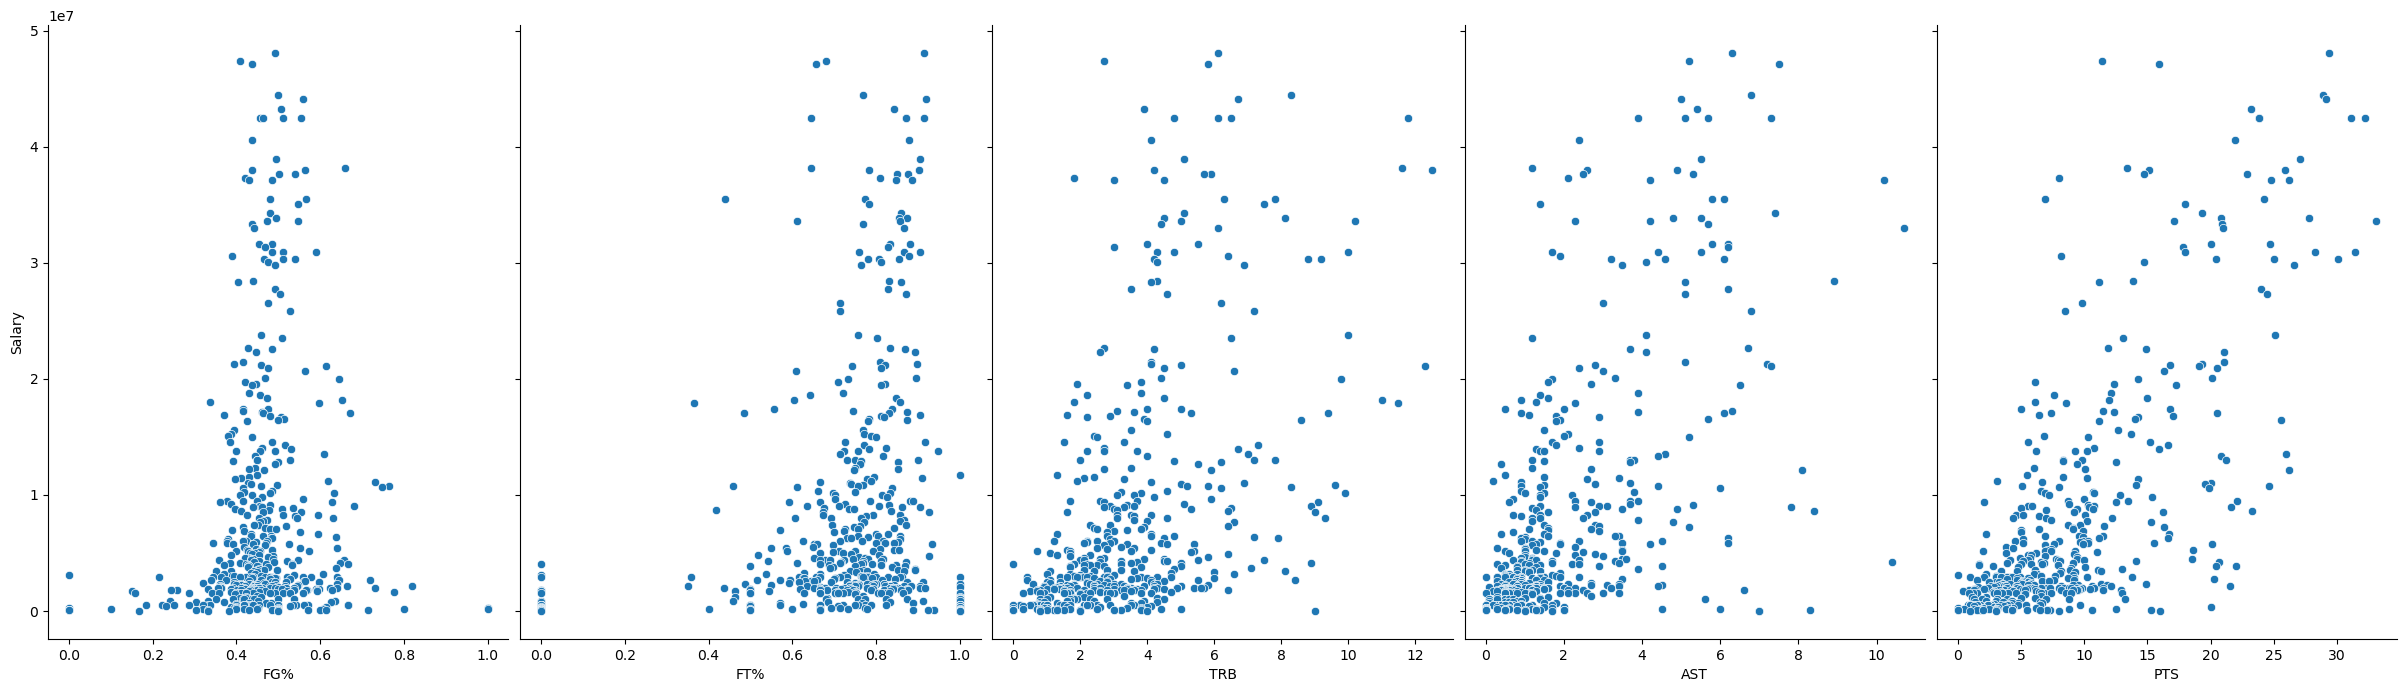

In [99]:
#Check Linearity Assumpton
p = sns.pairplot(df,
                x_vars=['FG%','FT%','TRB', 'AST','PTS'], 
                y_vars='Salary', size=7, aspect=0.7)

Multiple Linear Regression Model
Mean Squared Error (MSE): 45254539985871.8984
R-squared (R^2): 0.6591


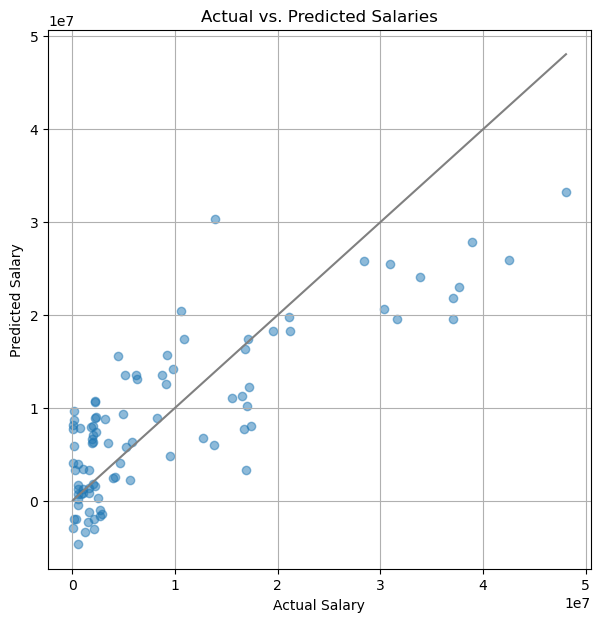

In [111]:
# Import necessary modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


# Train-Test Split
train_df, test_df, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = train_df.drop(['Player Name'], axis=1)
X_test = test_df.drop(['Player Name'], axis=1)

# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define and Train Regression Models
mlr_model = LinearRegression()

# Fit the model
mlr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = mlr_model.predict(X_test_scaled)

# Calculate MSE and R2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f'Multiple Linear Regression Model')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'R-squared (R^2): {r2:.4f}')

predictions_df = pd.DataFrame({
    'Player Name': test_df['Player Name'],
    'Minutes Played': test_df['MP'],
    'Games Played': test_df['GP'],
    'Actual Salary': y_test,
    'Predicted Salary': y_pred
})

# Plot actual vs. predicted salaries
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title('Actual vs. Predicted Salaries')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='solid', color='gray')
plt.grid(True)
plt.show()

In [109]:
predictions_df['Absolute Difference'] = predictions_df['Actual Salary'] - predictions_df['Predicted Salary']
predictions_df['Percentage Difference'] = (predictions_df['Absolute Difference'] / predictions_df['Predicted Salary']) * 100

predictions_df = predictions_df.loc[predictions_df['Minutes Played'] >= 15]
predictions_df = predictions_df.loc[predictions_df['Games Played'] >= 20]
# Sort by percentage difference
#predictions_df.sort_values(by='Percentage Difference', ascending=False)
predictions_df['Salary_Pred_Rank'] = predictions_df['Percentage Difference'].rank(ascending=False)
predictions_df = predictions_df.sort_values(by='Salary_Pred_Rank')
predictions_df.head()



,Player Name,Minutes Played,Games Played,Actual Salary,Predicted Salary,Absolute Difference,Percentage Difference,Salary_Pred_Rank
76,Duncan Robinson,16.5,42,16902000,3.328426e+06,1.357357e+07,407.807525,1.0
185,Romeo Langford,19.6,43,5634257,2.229884e+06,3.404373e+06,152.670386,2.0
93,Luke Kennard,22.3,59,13745455,6.013204e+06,7.732251e+06,128.587864,3.0
78,Collin Sexton,23.9,48,16700000,7.665724e+06,9.034276e+06,117.852884,4.0
126,Landry Shamet,20.2,40,9500000,4.809575e+06,4.690425e+06,97.522647,5.0


In [110]:
predictions_df.tail()

,Player Name,Minutes Played,Games Played,Actual Salary,Predicted Salary,Absolute Difference,Percentage Difference,Salary_Pred_Rank
298,Bones Hyland,19.4,56,2201520,8.882669e+06,-6.681149e+06,-75.215556,50.0
324,Thomas Bryant,18.3,59,1968175,8.050638e+06,-6.082463e+06,-75.552559,51.0
351,Naji Marshall,23.3,77,1782621,7.949125e+06,-6.166504e+06,-77.574626,52.0
299,Bol Bol,21.5,70,2200000,1.058379e+07,-8.383791e+06,-79.213497,53.0
302,Jaden McDaniels,30.6,79,2161440,1.077275e+07,-8.611308e+06,-79.936040,54.0
